In [ ]:
# Project Header and Imports
"""
DenseNet-121 Baseline Model for NIH Chest X-ray Classification
COSC 4368 Final Project - Group 13
Yla Herrera, Nicolas Mangilit, Kiriti Padavala, and Matt Tindall
"""

# --- Standard Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
from pathlib import Path

# --- PyTorch ---
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

# --- Sklearn ---
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from sklearn.model_selection import train_test_split

from tqdm import tqdm

print("All libraries imported successfully in Google Colab!")


All libraries imported successfully in Google Colab!


**Setup**

In [ ]:
# Set Random Seeds and Check Device

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ GPU not detected. Go to Runtime > Change runtime type > GPU")


Using device: cuda
GPU: NVIDIA A100-SXM4-40GB


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Define Paths
DATA_DIR = "/content/drive/MyDrive/AI Project/data"

# Load metadata
print("Loading metadata CSV...")
csv_path = os.path.join(DATA_DIR, "Data_Entry_2017.csv")

df = pd.read_csv(csv_path)

print(f"✓ Total number of images: {len(df)}")
print("\nDataset columns:")
print(df.columns.tolist())
print("\nFirst few rows:")
print(df.head())

# Check image folders
print("\nChecking for image folders...")
image_folders = []

for i in range(1, 13):
    folder_name = f"images_{i:03d}"
    folder_path = os.path.join(DATA_DIR, folder_name)

    if os.path.exists(folder_path):
        num_images = len([f for f in os.listdir(folder_path) if f.endswith(".png")])
        image_folders.append(folder_name)
        print(f"Found {folder_name} with {num_images} images")

print(f"\nTotal image folders found: {len(image_folders)}")


Mounted at /content/drive
Loading metadata CSV...
✓ Total number of images: 112120

Dataset columns:
['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11']

First few rows:
        Image Index          Finding Labels  Follow-up #  Patient ID  \
0  00000001_000.png            Cardiomegaly            0           1   
1  00000001_001.png  Cardiomegaly|Emphysema            1           1   
2  00000001_002.png   Cardiomegaly|Effusion            2           1   
3  00000002_000.png              No Finding            0           2   
4  00000003_000.png                  Hernia            0           3   

   Patient Age Patient Gender View Position  OriginalImage[Width  Height]  \
0           58              M            PA                 2682     2749   
1           58              M            PA                 2894     2729   
2           58     

In [ ]:
# Check image folders and count images inside the nested "images" folder
print("\nChecking for image folders...")
image_folders = []

for i in range(1, 13):
    folder_name = f"images_{i:03d}"
    folder_path = os.path.join(DATA_DIR, folder_name, "images")

    if os.path.exists(folder_path):
        num_images = len([f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        image_folders.append(folder_name)
        print(f"Found {folder_name} with {num_images} images")
    else:
        print(f"Folder {folder_name}/images not found!")

print(f"\nTotal image folders found: {len(image_folders)}")



Checking for image folders...
Found images_001 with 4999 images
Found images_002 with 10000 images
Found images_003 with 10012 images
Found images_004 with 10000 images
Found images_005 with 10000 images
Found images_006 with 10000 images
Found images_007 with 10000 images
Found images_008 with 10000 images
Found images_009 with 10000 images
Found images_010 with 10000 images
Found images_011 with 10000 images
Found images_012 with 7121 images

Total image folders found: 12


In [ ]:
# Define Disease Categories
DISEASE_CATEGORIES = [
    'Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration',
    'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax',
    'Consolidation', 'Edema', 'Emphysema', 'Fibrosis',
    'Pleural_Thickening', 'Hernia'
]

print(f"Number of disease categories: {len(DISEASE_CATEGORIES)}")
print(f"Disease categories: {DISEASE_CATEGORIES}")


Number of disease categories: 14
Disease categories: ['Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax', 'Consolidation', 'Edema', 'Emphysema', 'Fibrosis', 'Pleural_Thickening', 'Hernia']



Disease distribution:
Infiltration          19894
Effusion              13317
Atelectasis           11559
Nodule                 6331
Mass                   5782
Pneumothorax           5302
Consolidation          4667
Pleural_Thickening     3385
Cardiomegaly           2776
Emphysema              2516
Edema                  2303
Fibrosis               1686
Pneumonia              1431
Hernia                  227
dtype: int64


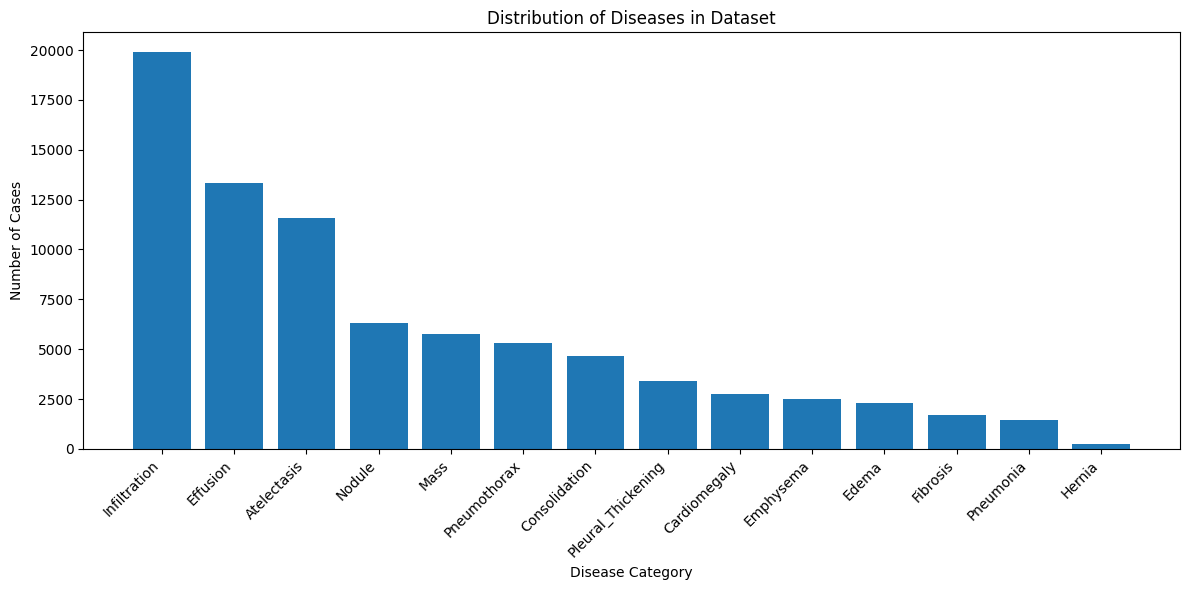

In [ ]:
# Parse Labels and Create Binary Columns

def parse_labels(label_string, disease_categories):
    """
    Convert label string ('Mass|Nodule') into a multi-hot encoded vector.
    Handles 'No Finding' properly.
    """
    labels = np.zeros(len(disease_categories))
    if label_string != "No Finding":
        diseases = label_string.split('|')
        for disease in diseases:
            if disease in disease_categories:
                labels[disease_categories.index(disease)] = 1
    return labels


# Add binary label columns safely (avoids substring matching issues)
for disease in DISEASE_CATEGORIES:
    df[disease] = df['Finding Labels'].apply(
        lambda x: 1 if disease in x.split('|') else 0
    )

print("\nDisease distribution:")
print(df[DISEASE_CATEGORIES].sum().sort_values(ascending=False))
#ployt
plt.figure(figsize=(12, 6))

disease_counts = df[DISEASE_CATEGORIES].sum().sort_values(ascending=False)

plt.bar(range(len(disease_counts)), disease_counts.values)
plt.xticks(
    range(len(disease_counts)),
    disease_counts.index,
    rotation=45,
    ha='right'
)
plt.xlabel('Disease Category')
plt.ylabel('Number of Cases')
plt.title('Distribution of Diseases in Dataset')
plt.tight_layout()
plt.show()


**Baseline ResNet-18**

In [ ]:

from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

class ChestXrayDataset(Dataset):
    """
    Custom Dataset for NIH Chest X-rays.

    image_dir may be a single path or a list of directories.
    __getitem__ searches each folder in order for the image file.
    """

    def __init__(self, dataframe, image_dir, disease_categories, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)

        # Allow single or multiple image roots
        if isinstance(image_dir, (list, tuple)):
            self.image_dirs = list(image_dir)
        else:
            self.image_dirs = [image_dir]

        self.image_dir = image_dir
        self.disease_categories = disease_categories
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # Get filename
        img_name = self.dataframe.loc[idx, 'Image Index']

        # Search for file in all directory roots
        img_path = None
        for root in self.image_dirs:
            candidate = os.path.join(root, img_name)
            if os.path.exists(candidate):
                img_path = candidate
                break

        if img_path is None:
            raise FileNotFoundError(
                f"Image '{img_name}' not found in any of: {self.image_dirs}"
            )

        # Load image
        image = Image.open(img_path).convert('RGB')

        labels = self.dataframe.loc[idx, self.disease_categories].values.astype(np.float32)

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(labels)


In [ ]:
# Define transforms for training and validation

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("Data transforms defined:")
print("  - Train: Resize(224x224), RandomHorizontalFlip, ToTensor, Normalize")
print("  - Val:   Resize(224x224), ToTensor, Normalize")


Data transforms defined:
  - Train: Resize(224x224), RandomHorizontalFlip, ToTensor, Normalize
  - Val:   Resize(224x224), ToTensor, Normalize


In [ ]:
# Train/Validation Split

# 80/20 split of the full dataframe
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

train_df = train_df.sample(n=4000, random_state=42)
val_df = val_df.sample(n=1000, random_state=42)

print(f"Train set size: {len(train_df)}")
print(f"Validation set size: {len(val_df)}")

print("\nTrain/Val split ratio relative to ORIGINAL dataset:")
print(f"  Train: {len(train_df)/len(df):.2%}")
print(f"  Val:   {len(val_df)/len(df):.2%}")


Train set size: 4000
Validation set size: 1000

Train/Val split ratio relative to ORIGINAL dataset:
  Train: 3.57%
  Val:   0.89%


In [ ]:
DATA_DIR = "/content/drive/MyDrive/AI Project/data"

# The NIH dataset has multiple directories: images_001 ... images_012
IMAGE_DIRS = [os.path.join(DATA_DIR, f"images_{i:03d}", "images")
              for i in range(1, 13)]

# Keep only directories that actually exist
IMAGE_DIRS = [p for p in IMAGE_DIRS if os.path.exists(p)]

# Build train + validation datasets
train_dataset = ChestXrayDataset(
    train_df,
    IMAGE_DIRS,
    DISEASE_CATEGORIES,
    transform=train_transform
)
val_dataset = ChestXrayDataset(
    val_df,
    IMAGE_DIRS,
    DISEASE_CATEGORIES,
    transform=val_transform
)

BATCH_SIZE = 256
NUM_WORKERS = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("\nDataLoaders created with new BATCH_SIZE:")
print(f"  - Batch size: {BATCH_SIZE}")
print(f"  - Train batches: {len(train_loader)}")
print(f"  - Val batches: {len(val_loader)}")
print(f"  - Num workers: {NUM_WORKERS}")


DataLoaders created with new BATCH_SIZE:
  - Batch size: 256
  - Train batches: 16
  - Val batches: 4
  - Num workers: 4


In [ ]:
import torch.cuda.amp as amp

# Initialize GradScaler for mixed precision training
scaler = torch.amp.GradScaler('cuda')

print("✓ torch.cuda.amp imported and GradScaler initialized.")

✓ torch.cuda.amp imported and GradScaler initialized.


In [ ]:
# verify datasets & that an example image file exists
print('IMAGE_DIRS:', IMAGE_DIRS)
print('Train dataset length:', len(train_dataset))
print('Val dataset length:', len(val_dataset))

# Helper function to locate a filename inside the configured roots
def find_image_path(image_name, search_dirs):
    for d in search_dirs:
        candidate = os.path.join(d, image_name)
        if os.path.exists(candidate):
            return candidate
    return None

# Pick a sample image from the train set
sample_name = train_df.iloc[0]['Image Index']
print('Sample image name (from train_df):', sample_name)

found = find_image_path(sample_name, IMAGE_DIRS)
if found:
    print('Found sample path:', found)
else:
    print("Sample image not found. Make sure your dataset paths are correct and Drive is mounted.")


IMAGE_DIRS: ['/content/drive/MyDrive/AI Project/data/images_001/images', '/content/drive/MyDrive/AI Project/data/images_002/images', '/content/drive/MyDrive/AI Project/data/images_003/images', '/content/drive/MyDrive/AI Project/data/images_004/images', '/content/drive/MyDrive/AI Project/data/images_005/images', '/content/drive/MyDrive/AI Project/data/images_006/images', '/content/drive/MyDrive/AI Project/data/images_007/images', '/content/drive/MyDrive/AI Project/data/images_008/images', '/content/drive/MyDrive/AI Project/data/images_009/images', '/content/drive/MyDrive/AI Project/data/images_010/images', '/content/drive/MyDrive/AI Project/data/images_011/images', '/content/drive/MyDrive/AI Project/data/images_012/images']
Train dataset length: 4000
Val dataset length: 1000
Sample image name (from train_df): 00005750_025.png
Found sample path: /content/drive/MyDrive/AI Project/data/images_003/images/00005750_025.png


In [ ]:
# Define Loss Function and Optimizer

import torch.nn as nn
import torch.optim as optim

# Binary Cross Entropy with Logits Loss (multi-label)
criterion = nn.BCEWithLogitsLoss()

# Adam optimizer
LEARNING_RATE = 1e-4
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Learning rate scheduler (reduce LR on plateau)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

print("Loss function: BCEWithLogitsLoss")
print(f"Optimizer: Adam (lr={LEARNING_RATE})")
print("Scheduler: ReduceLROnPlateau")
print(f"Device: {device} ({'GPU' if device.type=='cuda' else 'CPU'})")


Loss function: BCEWithLogitsLoss
Optimizer: Adam (lr=0.0001)
Scheduler: ReduceLROnPlateau
Device: cuda (GPU)


In [ ]:
from tqdm import tqdm

# Training function for one epoch with AMP
def train_epoch(model, dataloader, criterion, optimizer, device, scaler):
    """
    Train the model for one epoch with Automatic Mixed Precision (AMP).
    Returns the average loss over the epoch.
    """
    model.train()
    running_loss = 0.0

    for images, labels in tqdm(dataloader, desc="Training with AMP", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        # Zero gradients
        optimizer.zero_grad()

        # Forward pass with automatic mixed precision
        with torch.amp.autocast('cuda'): # Updated to recommended syntax
            outputs = model(images)
            loss = criterion(outputs, labels)

        # Backward pass and optimization with GradScaler
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Accumulate loss
        running_loss += loss.item() * images.size(0)

    if device.type == 'cuda':
        torch.cuda.empty_cache()

    epoch_loss = running_loss / len(dataloader.dataset)
    return epoch_loss

print("Training function updated for AMP integration!")

Training function updated for AMP integration!


In [ ]:
from tqdm import tqdm
from sklearn.metrics import roc_auc_score
import numpy as np
import torch

# Validation function for one epoch with AMP
def validate_epoch(model, dataloader, criterion, device):
    """
    Validate the model for one epoch with Automatic Mixed Precision (AMP).
    Returns:
        - average loss
        - mean AUC across all diseases
        - list of AUCs per disease
    """
    model.eval()
    running_loss = 0.0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Validation with AMP", leave=False):
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass with automatic mixed precision
            with torch.amp.autocast('cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            # Store predictions and labels for metrics
            all_labels.append(labels.cpu().numpy())
            all_preds.append(torch.sigmoid(outputs).cpu().numpy())

#free GPU memory
    if device.type == 'cuda':
        torch.cuda.empty_cache()

    # Compute average loss
    epoch_loss = running_loss / len(dataloader.dataset)

    # Concatenate all batches
    all_labels = np.concatenate(all_labels, axis=0)
    all_preds = np.concatenate(all_preds, axis=0)

    # Calculate AUC for each disease
    auc_scores = []
    for i in range(all_labels.shape[1]):
        if len(np.unique(all_labels[:, i])) > 1:  # Both classes present
            auc = roc_auc_score(all_labels[:, i], all_preds[:, i])
            auc_scores.append(auc)
        else:
            auc_scores.append(np.nan)

    mean_auc = np.nanmean(auc_scores)

    return epoch_loss, mean_auc, auc_scores

print("Validation function updated for AMP integration!")

Validation function updated for AMP integration!


In [ ]:
print("Generating binary disease columns for oversampled_train_df...")

# Apply the label parsing to the oversampled_train_df
for disease in DISEASE_CATEGORIES:
    oversampled_train_df[disease] = oversampled_train_df['Finding Labels'].apply(
        lambda x: 1 if disease in x.split('|') else 0
    )

print(f"✓ Binary disease columns added to oversampled_train_df. Total rows: {len(oversampled_train_df)}")
print("First few rows of oversampled_train_df with new binary columns:")
print(oversampled_train_df.head())
print("Disease distribution in oversampled_train_df:")
print(oversampled_train_df[DISEASE_CATEGORIES].sum().sort_values(ascending=False))

Generating binary disease columns for oversampled_train_df...
✓ Binary disease columns added to oversampled_train_df. Total rows: 8339
First few rows of oversampled_train_df with new binary columns:
        Image Index                             Finding Labels  Follow-up #  \
0  00005750_025.png                      Effusion|Infiltration           25   
1  00007757_001.png                                 No Finding            1   
2  00029676_005.png                                 No Finding            5   
3  00016577_013.png                                Atelectasis           13   
4  00013012_000.png  Cardiomegaly|Effusion|Infiltration|Nodule            0   

   Patient ID  Patient Age Patient Gender View Position  OriginalImage[Width  \
0        5750           24              M            AP                 2500   
1        7757           55              F            AP                 2500   
2       29676           37              M            AP                 3056   
3     

##ResNet-18

In [ ]:
import torch.nn as nn
from torchvision import models

class ResNet18(nn.Module):
    """ResNet-18 for multi-label chest X-ray classification"""

    def __init__(self, num_classes=14, pretrained=True):
        super(ResNet18, self).__init__()

        # Load pre-trained ResNet-18 (downloads weights if pretrained=True)
        self.resnet = models.resnet18(pretrained=pretrained)

        # Number of input features for the classifier
        num_features = self.resnet.fc.in_features

        # Replace classifier for multi-label classification
        self.resnet.fc = nn.Linear(num_features, num_classes)

    def forward(self, x):
        return self.resnet(x)

print("ResNet18 model class defined for Colab!")

ResNet18 model class defined for Colab!


In [ ]:
print("\n" + "="*60)
print("TRAINING RESNET-18 BASELINE MODEL")
print("="*60)

# 1. Initialize a new ResNet-18 model
model_resnet_baseline = ResNet18(num_classes=len(DISEASE_CATEGORIES), pretrained=True).to(device)

# 2. Define the loss function
criterion_resnet_baseline = nn.BCEWithLogitsLoss()

# 3. Initialize the Adam optimizer
LEARNING_RATE_RESNET_BASELINE = 1e-4
optimizer_resnet_baseline = optim.Adam(model_resnet_baseline.parameters(), lr=LEARNING_RATE_RESNET_BASELINE)

# 4. Set up a learning rate scheduler
scheduler_resnet_baseline = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_resnet_baseline, mode='min', factor=0.5, patience=2
)

# 5. Define NUM_EPOCHS for ResNet-18 baseline training
NUM_EPOCHS_RESNET_BASELINE = 10

print(f"ResNet-18 model initialized on {device}, ready for training over {NUM_EPOCHS_RESNET_BASELINE} epochs.")

# 6. Create empty lists to store metrics
train_losses_resnet_baseline = []
val_losses_resnet_baseline = []
val_aucs_resnet_baseline = []

best_val_auc_resnet_baseline = 0.0
MODEL_SAVE_PATH_RESNET_BASELINE = "resnet18_baseline.pth"

# 7. Loop through the specified number of epochs
for epoch in range(NUM_EPOCHS_RESNET_BASELINE):
    print(f"\n=== Epoch {epoch+1}/{NUM_EPOCHS_RESNET_BASELINE} (ResNet-18 Baseline) ===")

    # a. Train epoch with AMP
    train_loss_resnet_baseline_epoch = train_epoch(
        model_resnet_baseline, train_loader, criterion_resnet_baseline,
        optimizer_resnet_baseline, device, scaler
    )
    train_losses_resnet_baseline.append(train_loss_resnet_baseline_epoch)

    # b. Validate epoch with AMP
    val_loss_resnet_baseline_epoch, mean_auc_resnet_baseline_epoch, _ = validate_epoch(
        model_resnet_baseline, val_loader, criterion_resnet_baseline, device
    )
    val_losses_resnet_baseline.append(val_loss_resnet_baseline_epoch)
    val_aucs_resnet_baseline.append(mean_auc_resnet_baseline_epoch)

    # c. Step the scheduler
    scheduler_resnet_baseline.step(val_loss_resnet_baseline_epoch)

    # d. Print metrics
    print(f"Train Loss: {train_loss_resnet_baseline_epoch:.4f} | Val Loss: {val_loss_resnet_baseline_epoch:.4f} | Mean AUC: {mean_auc_resnet_baseline_epoch:.4f}")
    print(f"Current LR: {optimizer_resnet_baseline.param_groups[0]['lr']:.2e}")

    # e. Save best model
    if mean_auc_resnet_baseline_epoch > best_val_auc_resnet_baseline:
        best_val_auc_resnet_baseline = mean_auc_resnet_baseline_epoch
        torch.save(model_resnet_baseline.state_dict(), MODEL_SAVE_PATH_RESNET_BASELINE)
        print(f"New best model saved with Mean AUC: {best_val_auc_resnet_baseline:.4f}")

print("\n" + "="*60)
print("ResNet-18 Baseline Training Complete!")
print("="*60)


TRAINING RESNET-18 BASELINE MODEL


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet-18 model initialized on cuda, ready for training over 10 epochs.

=== Epoch 1/10 (ResNet-18 Baseline) ===


Train Loss: 0.5984 | Val Loss: 0.5539 | Mean AUC: 0.6044
Current LR: 1.00e-04
New best model saved with Mean AUC: 0.6044

=== Epoch 2/10 (ResNet-18 Baseline) ===


Train Loss: 0.3166 | Val Loss: 0.2729 | Mean AUC: 0.6281
Current LR: 1.00e-04
New best model saved with Mean AUC: 0.6281

=== Epoch 3/10 (ResNet-18 Baseline) ===


...

Train Loss: 0.1713 | Val Loss: 0.1765 | Mean AUC: 0.7153
Current LR: 1.00e-04
New best model saved with Mean AUC: 0.7153

=== Epoch 7/10 (ResNet-18 Baseline) ===


Train Loss: 0.1631 | Val Loss: 0.1761 | Mean AUC: 0.7257
Current LR: 1.00e-04
New best model saved with Mean AUC: 0.7257

=== Epoch 8/10 (ResNet-18 Baseline) ===


Train Loss: 0.1546 | Val Loss: 0.1747 | Mean AUC: 0.7170
Current LR: 1.00e-04

=== Epoch 9/10 (ResNet-18 Baseline) ===


Train Loss: 0.1447 | Val Loss: 0.1737 | Mean AUC: 0.7215
Current LR: 1.00e-04

=== Epoch 10/10 (ResNet-18 Baseline) ===


Train Loss: 0.1332 | Val Loss: 0.1791 | Mean AUC: 0.7264
Current LR: 1.00e-04
New best model saved with Mean AUC: 0.7264

ResNet-18 Baseline Training Complete!


Generating training curves and summary for ResNet-18 baseline model...


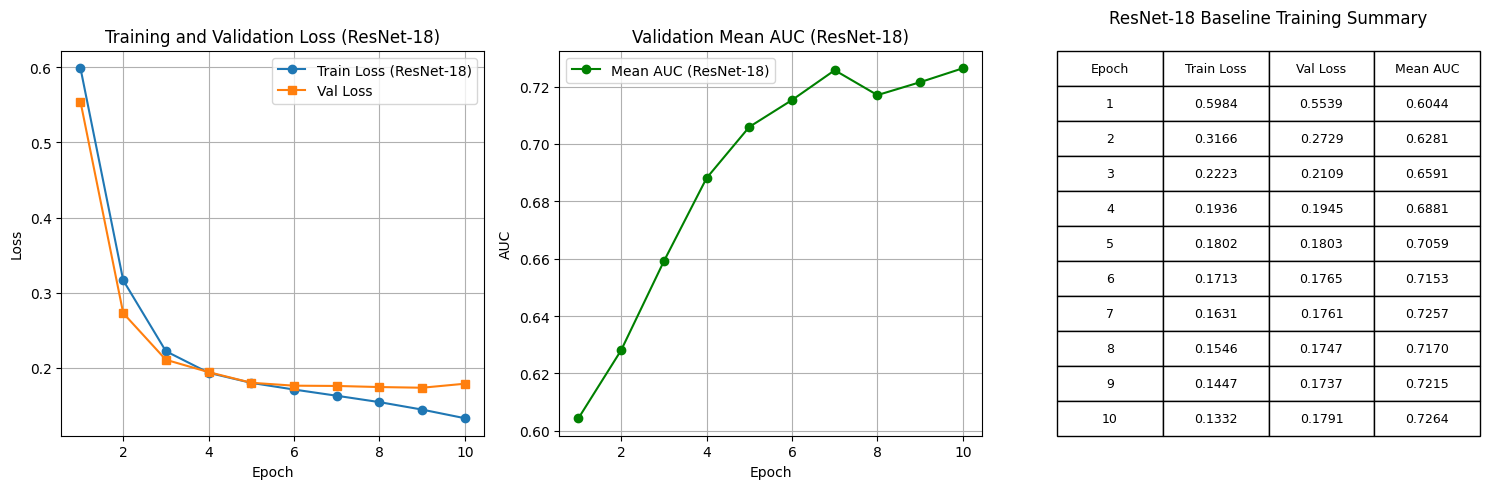

Training curves for ResNet-18 baseline model saved to 'resnet18_baseline_training_curves.png'

RESNET-18 BASELINE MODEL FINAL RESULTS SUMMARY
Best Validation AUC: 0.7264 (Epoch 10)
Final Validation AUC: 0.7264
Final Train Loss: 0.1332
Final Val Loss: 0.1791
ResNet-18 baseline model evaluation complete!


In [ ]:
import matplotlib.pyplot as plt
import torch

print("Generating training curves and summary for ResNet-18 baseline model...")

# Plot Training Curves
plt.figure(figsize=(15, 5))

# Loss curves
plt.subplot(1, 3, 1)
plt.plot(range(1, NUM_EPOCHS_RESNET_BASELINE + 1), train_losses_resnet_baseline, marker='o', label='Train Loss (ResNet-18)')
plt.plot(range(1, NUM_EPOCHS_RESNET_BASELINE + 1), val_losses_resnet_baseline, marker='s', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss (ResNet-18)')
plt.legend()
plt.grid(True)

# AUC curve
plt.subplot(1, 3, 2)
plt.plot(range(1, NUM_EPOCHS_RESNET_BASELINE + 1), val_aucs_resnet_baseline, marker='o', color='green', label='Mean AUC (ResNet-18)')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.title('Validation Mean AUC (ResNet-18)')
plt.legend()
plt.grid(True)

# Summary table
plt.subplot(1, 3, 3)
plt.axis('off')
summary_data_resnet_baseline = [
    [i + 1, f"{train_losses_resnet_baseline[i]:.4f}", f"{val_losses_resnet_baseline[i]:.4f}", f"{val_aucs_resnet_baseline[i]:.4f}"]
    for i in range(NUM_EPOCHS_RESNET_BASELINE)
]

table = plt.table(cellText=summary_data_resnet_baseline,
                  colLabels=['Epoch', 'Train Loss', 'Val Loss', 'Mean AUC'],
                  cellLoc='center',
                  loc='center',
                  bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)
plt.title('ResNet-18 Baseline Training Summary', pad=20)

plt.tight_layout()
plt.savefig('resnet18_baseline_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("Training curves for ResNet-18 baseline model saved to 'resnet18_baseline_training_curves.png'")

# Final Results Summary for ResNet-18 Baseline Model
print("\n" + "="*60)
print("RESNET-18 BASELINE MODEL FINAL RESULTS SUMMARY")
print("="*60)
best_auc_idx_resnet_baseline = val_aucs_resnet_baseline.index(max(val_aucs_resnet_baseline))
print(f"Best Validation AUC: {max(val_aucs_resnet_baseline):.4f} (Epoch {best_auc_idx_resnet_baseline+1})")
print(f"Final Validation AUC: {val_aucs_resnet_baseline[-1]:.4f}")
print(f"Final Train Loss: {train_losses_resnet_baseline[-1]:.4f}")
print(f"Final Val Loss: {val_losses_resnet_baseline[-1]:.4f}")
print("="*60)
print("ResNet-18 baseline model evaluation complete!")
print("===========================================================")


##Oversampling

In [ ]:
print("\n" + "="*60)
print("TRAINING RESNET-18 MODEL WITH OVERSAMPLED DATA")
print("="*60)

# 1. Initialize a new ResNet-18 model
model_resnet_oversampled = ResNet18(num_classes=len(DISEASE_CATEGORIES), pretrained=True).to(device)

# 2. Define the loss function
criterion_resnet_oversampled = nn.BCEWithLogitsLoss()

# 3. Initialize the Adam optimizer
LEARNING_RATE_RESNET_OVERSAMPLED = 1e-4
optimizer_resnet_oversampled = optim.Adam(model_resnet_oversampled.parameters(), lr=LEARNING_RATE_RESNET_OVERSAMPLED)

# 4. Set up a learning rate scheduler
scheduler_resnet_oversampled = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_resnet_oversampled, mode='min', factor=0.5, patience=2
)

# 5. Define NUM_EPOCHS for ResNet-18 oversampled training
NUM_EPOCHS_RESNET_OVERSAMPLED = 10

print(f"ResNet-18 model initialized on {device}, ready for training over {NUM_EPOCHS_RESNET_OVERSAMPLED} epochs with oversampled data.")

# 6. Create empty lists to store metrics
train_losses_resnet_oversampled = []
val_losses_resnet_oversampled = []
val_aucs_resnet_oversampled = []

best_val_auc_resnet_oversampled = 0.0
MODEL_SAVE_PATH_RESNET_OVERSAMPLED = "resnet18_oversampled.pth"

# 7. Loop through the specified number of epochs
for epoch in range(NUM_EPOCHS_RESNET_OVERSAMPLED):
    print(f"\n=== Epoch {epoch+1}/{NUM_EPOCHS_RESNET_OVERSAMPLED} (ResNet-18 Oversampled) ===")

    # a. Train epoch with AMP using the oversampled_train_loader
    train_loss_resnet_oversampled_epoch = train_epoch(
        model_resnet_oversampled, oversampled_train_loader, criterion_resnet_oversampled,
        optimizer_resnet_oversampled, device, scaler
    )
    train_losses_resnet_oversampled.append(train_loss_resnet_oversampled_epoch)

    # b. Validate epoch with AMP using the existing val_loader
    val_loss_resnet_oversampled_epoch, mean_auc_resnet_oversampled_epoch, _ = validate_epoch(
        model_resnet_oversampled, val_loader, criterion_resnet_oversampled, device
    )
    val_losses_resnet_oversampled.append(val_loss_resnet_oversampled_epoch)
    val_aucs_resnet_oversampled.append(mean_auc_resnet_oversampled_epoch)

    # c. Step the scheduler
    scheduler_resnet_oversampled.step(val_loss_resnet_oversampled_epoch)

    # d. Print metrics
    print(f"Train Loss: {train_loss_resnet_oversampled_epoch:.4f} | Val Loss: {val_loss_resnet_oversampled_epoch:.4f} | Mean AUC: {mean_auc_resnet_oversampled_epoch:.4f}")
    print(f"Current LR: {optimizer_resnet_oversampled.param_groups[0]['lr']:.2e}")

    # e. Save best model
    if mean_auc_resnet_oversampled_epoch > best_val_auc_resnet_oversampled:
        best_val_auc_resnet_oversampled = mean_auc_resnet_oversampled_epoch
        torch.save(model_resnet_oversampled.state_dict(), MODEL_SAVE_PATH_RESNET_OVERSAMPLED)
        print(f"New best model saved with Mean AUC: {best_val_auc_resnet_oversampled:.4f}")

print("\n" + "="*60)
print("ResNet-18 Oversampled Model Training Complete!")
print("="*60)


TRAINING RESNET-18 MODEL WITH OVERSAMPLED DATA


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet-18 model initialized on cuda, ready for training over 10 epochs with oversampled data.

=== Epoch 1/10 (ResNet-18 Oversampled) ===


Train Loss: 0.5490 | Val Loss: 0.4829 | Mean AUC: 0.6413
Current LR: 1.00e-04
New best model saved with Mean AUC: 0.6413

=== Epoch 2/10 (ResNet-18 Oversampled) ===


Train Loss: 0.2939 | Val Loss: 0.2543 | Mean AUC: 0.6834
Current LR: 1.00e-04
New best model saved with Mean AUC: 0.6834

=== Epoch 3/10 (ResNet-18 Oversampled) ===


...

Train Loss: 0.1525 | Val Loss: 0.1763 | Mean AUC: 0.7317
Current LR: 1.00e-04
New best model saved with Mean AUC: 0.7317

=== Epoch 7/10 (ResNet-18 Oversampled) ===


Train Loss: 0.1367 | Val Loss: 0.1769 | Mean AUC: 0.7209
Current LR: 1.00e-04

=== Epoch 8/10 (ResNet-18 Oversampled) ===


Train Loss: 0.1187 | Val Loss: 0.1777 | Mean AUC: 0.7169
Current LR: 1.00e-04

=== Epoch 9/10 (ResNet-18 Oversampled) ===


Train Loss: 0.1009 | Val Loss: 0.1808 | Mean AUC: 0.7057
Current LR: 5.00e-05

=== Epoch 10/10 (ResNet-18 Oversampled) ===


Train Loss: 0.0861 | Val Loss: 0.1817 | Mean AUC: 0.7074
Current LR: 5.00e-05

ResNet-18 Oversampled Model Training Complete!


Generating training curves and summary for ResNet-18 oversampled model...


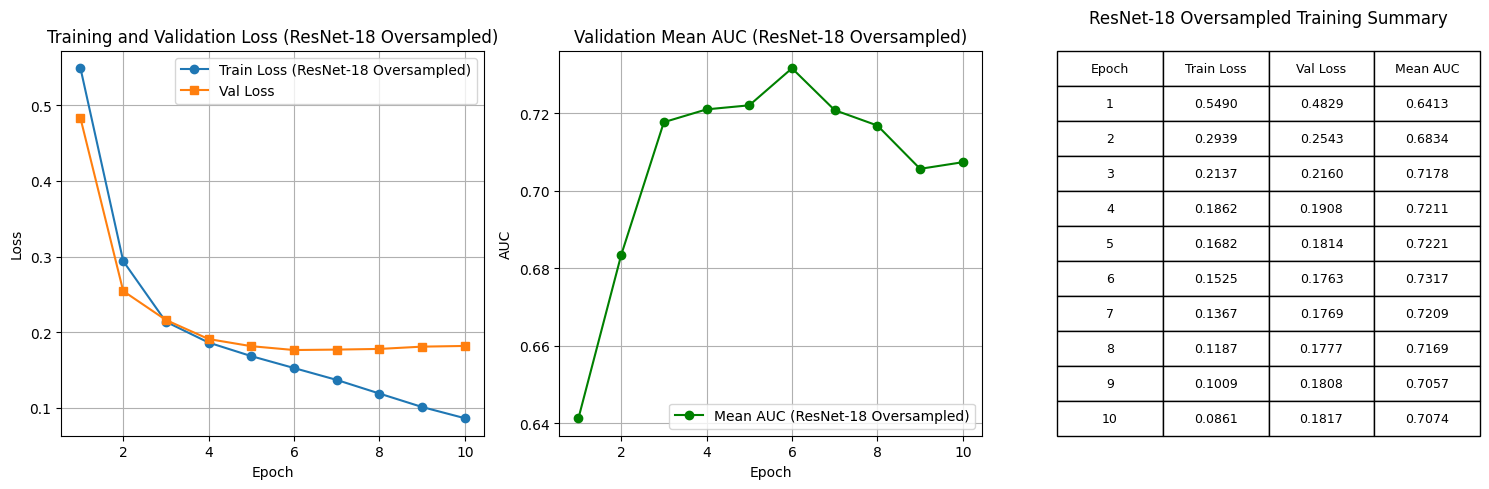

Training curves for ResNet-18 oversampled model saved to 'resnet18_oversampled_training_curves.png'

RESNET-18 OVERSAMPLED MODEL FINAL RESULTS SUMMARY
Best Validation AUC: 0.7317 (Epoch 6)
Final Validation AUC: 0.7074
Final Train Loss: 0.0861
Final Val Loss: 0.1817
ResNet-18 oversampled model evaluation complete!


In [ ]:
import matplotlib.pyplot as plt
import torch

print("Generating training curves and summary for ResNet-18 oversampled model...")

# Plot Training Curves
plt.figure(figsize=(15, 5))

# Loss curves
plt.subplot(1, 3, 1)
plt.plot(range(1, NUM_EPOCHS_RESNET_OVERSAMPLED + 1), train_losses_resnet_oversampled, marker='o', label='Train Loss (ResNet-18 Oversampled)')
plt.plot(range(1, NUM_EPOCHS_RESNET_OVERSAMPLED + 1), val_losses_resnet_oversampled, marker='s', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss (ResNet-18 Oversampled)')
plt.legend()
plt.grid(True)

# AUC curve
plt.subplot(1, 3, 2)
plt.plot(range(1, NUM_EPOCHS_RESNET_OVERSAMPLED + 1), val_aucs_resnet_oversampled, marker='o', color='green', label='Mean AUC (ResNet-18 Oversampled)')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.title('Validation Mean AUC (ResNet-18 Oversampled)')
plt.legend()
plt.grid(True)

# Summary table
plt.subplot(1, 3, 3)
plt.axis('off')
summary_data_resnet_oversampled = [
    [i + 1, f"{train_losses_resnet_oversampled[i]:.4f}", f"{val_losses_resnet_oversampled[i]:.4f}", f"{val_aucs_resnet_oversampled[i]:.4f}"]
    for i in range(NUM_EPOCHS_RESNET_OVERSAMPLED)
]

table = plt.table(cellText=summary_data_resnet_oversampled,
                  colLabels=['Epoch', 'Train Loss', 'Val Loss', 'Mean AUC'],
                  cellLoc='center',
                  loc='center',
                  bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)
plt.title('ResNet-18 Oversampled Training Summary', pad=20)

plt.tight_layout()
plt.savefig('resnet18_oversampled_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("Training curves for ResNet-18 oversampled model saved to 'resnet18_oversampled_training_curves.png'")

# Final Results Summary for ResNet-18 Oversampled Model
print("\n" + "="*60)
print("RESNET-18 OVERSAMPLED MODEL FINAL RESULTS SUMMARY")
print("="*60)
best_auc_idx_resnet_oversampled = val_aucs_resnet_oversampled.index(max(val_aucs_resnet_oversampled))
print(f"Best Validation AUC: {max(val_aucs_resnet_oversampled):.4f} (Epoch {best_auc_idx_resnet_oversampled+1})")
print(f"Final Validation AUC: {val_aucs_resnet_oversampled[-1]:.4f}")
print(f"Final Train Loss: {train_losses_resnet_oversampled[-1]:.4f}")
print(f"Final Val Loss: {val_losses_resnet_oversampled[-1]:.4f}")
print("="*60)
print("ResNet-18 oversampled model evaluation complete!")
print("===========================================================")


##Reweighted Loss

In [ ]:
print("\n" + "="*60)
print("TRAINING RESNET-18 MODEL WITH REWEIGHTED LOSS")
print("="*60)

# 1. Initialize a new ResNet-18 model
model_resnet_reweighted = ResNet18(num_classes=len(DISEASE_CATEGORIES), pretrained=True).to(device)

# 2. Use the already defined criterion_reweighted as the loss function
criterion_resnet_reweighted = criterion_reweighted

# 3. Initialize the Adam optimizer
LEARNING_RATE_RESNET_RW = 1e-4 # Learning rate for the reweighted ResNet model
optimizer_resnet_reweighted = optim.Adam(model_resnet_reweighted.parameters(), lr=LEARNING_RATE_RESNET_RW)

# 4. Set up a learning rate scheduler
scheduler_resnet_reweighted = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_resnet_reweighted, mode='min', factor=0.5, patience=2
)

# 5. Define NUM_EPOCHS for reweighted training
NUM_EPOCHS_RESNET_RW = 10 # Adjust as needed

print(f"ResNet-18 model initialized on {device}, ready for training over {NUM_EPOCHS_RESNET_RW} epochs with reweighted loss.")

# 6. Create empty lists to store metrics
train_losses_resnet_rw = []
val_losses_resnet_rw = []
val_aucs_resnet_rw = []

best_val_auc_resnet_rw = 0.0
MODEL_SAVE_PATH_RESNET_RW = "resnet18_reweighted.pth"

# 7. Loop through the specified number of epochs
for epoch in range(NUM_EPOCHS_RESNET_RW):
    print(f"\n=== Epoch {epoch+1}/{NUM_EPOCHS_RESNET_RW} (ResNet-18 Reweighted Loss) ===")

    # a. Train epoch with AMP using the original train_loader and reweighted criterion
    train_loss_resnet_rw_epoch = train_epoch(
        model_resnet_reweighted, train_loader, criterion_resnet_reweighted,
        optimizer_resnet_reweighted, device, scaler
    )
    train_losses_resnet_rw.append(train_loss_resnet_rw_epoch)

    # b. Validate epoch with AMP using the original val_loader and reweighted criterion
    val_loss_resnet_rw_epoch, mean_auc_resnet_rw_epoch, _ = validate_epoch(
        model_resnet_reweighted, val_loader, criterion_resnet_reweighted, device
    )
    val_losses_resnet_rw.append(val_loss_resnet_rw_epoch)
    val_aucs_resnet_rw.append(mean_auc_resnet_rw_epoch)

    # c. Step the scheduler
    scheduler_resnet_reweighted.step(val_loss_resnet_rw_epoch)

    # d. Print metrics
    print(f"Train Loss: {train_loss_resnet_rw_epoch:.4f} | Val Loss: {val_loss_resnet_rw_epoch:.4f} | Mean AUC: {mean_auc_resnet_rw_epoch:.4f}")
    print(f"Current LR: {optimizer_resnet_reweighted.param_groups[0]['lr']:.2e}")

    # e. Save best model
    if mean_auc_resnet_rw_epoch > best_val_auc_resnet_rw:
        best_val_auc_resnet_rw = mean_auc_resnet_rw_epoch
        torch.save(model_resnet_reweighted.state_dict(), MODEL_SAVE_PATH_RESNET_RW)
        print(f"New best model saved with Mean AUC: {best_val_auc_resnet_rw:.4f}")

print("\n" + "="*60)
print("ResNet-18 Reweighted Model Training Complete!")
print("="*60)


TRAINING RESNET-18 MODEL WITH REWEIGHTED LOSS


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet-18 model initialized on cuda, ready for training over 10 epochs with reweighted loss.

=== Epoch 1/10 (ResNet-18 Reweighted Loss) ===


Train Loss: 1.3149 | Val Loss: 1.2319 | Mean AUC: 0.6426
Current LR: 1.00e-04
New best model saved with Mean AUC: 0.6426

=== Epoch 2/10 (ResNet-18 Reweighted Loss) ===


Train Loss: 1.0821 | Val Loss: 1.1861 | Mean AUC: 0.6860
Current LR: 1.00e-04
New best model saved with Mean AUC: 0.6860

=== Epoch 3/10 (ResNet-18 Reweighted Loss) ===


...

Train Loss: 0.5963 | Val Loss: 1.2077 | Mean AUC: 0.7341
Current LR: 1.00e-04
New best model saved with Mean AUC: 0.7341

=== Epoch 7/10 (ResNet-18 Reweighted Loss) ===


Train Loss: 0.5114 | Val Loss: 1.2722 | Mean AUC: 0.7254
Current LR: 5.00e-05

=== Epoch 8/10 (ResNet-18 Reweighted Loss) ===


Train Loss: 0.4469 | Val Loss: 1.3046 | Mean AUC: 0.7250
Current LR: 5.00e-05

=== Epoch 9/10 (ResNet-18 Reweighted Loss) ===


Train Loss: 0.4026 | Val Loss: 1.3496 | Mean AUC: 0.7232
Current LR: 5.00e-05

=== Epoch 10/10 (ResNet-18 Reweighted Loss) ===


Train Loss: 0.3663 | Val Loss: 1.3972 | Mean AUC: 0.7212
Current LR: 2.50e-05

ResNet-18 Reweighted Model Training Complete!


Generating training curves and summary for ResNet-18 reweighted model...


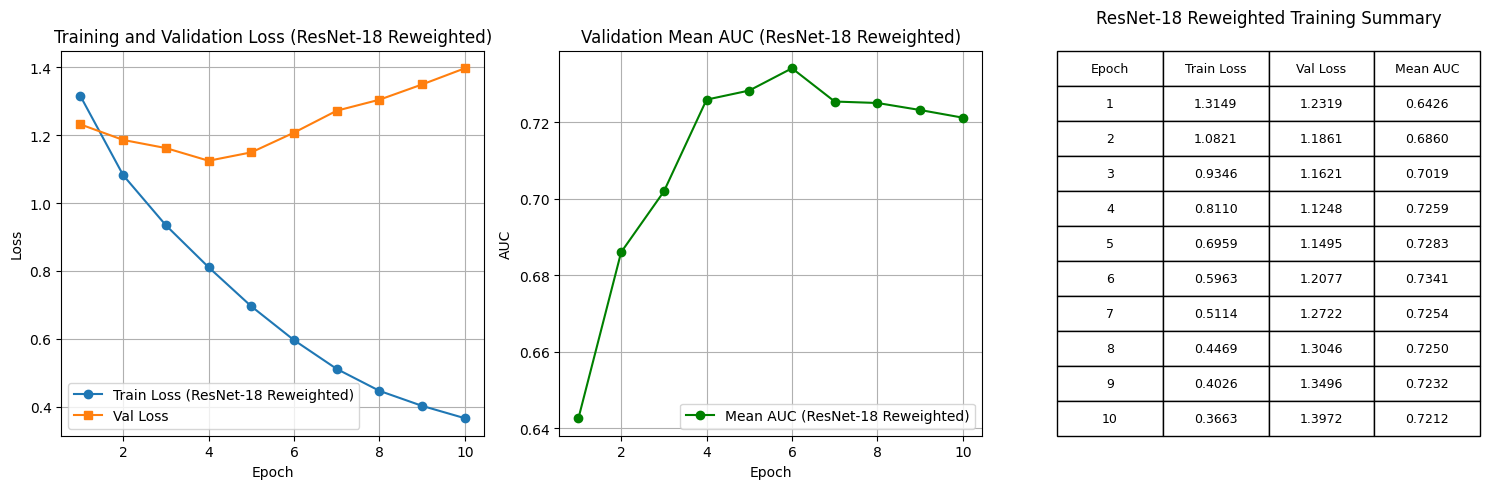

Training curves for ResNet-18 reweighted model saved to 'resnet18_reweighted_training_curves.png'

RESNET-18 REWEIGHTED MODEL FINAL RESULTS SUMMARY
Best Validation AUC: 0.7341 (Epoch 6)
Final Validation AUC: 0.7212
Final Train Loss: 0.3663
Final Val Loss: 1.3972
ResNet-18 reweighted model evaluation complete!


In [ ]:
import matplotlib.pyplot as plt
import torch

print("Generating training curves and summary for ResNet-18 reweighted model...")

# Plot Training Curves
plt.figure(figsize=(15, 5))

# Loss curves
plt.subplot(1, 3, 1)
plt.plot(range(1, NUM_EPOCHS_RESNET_RW + 1), train_losses_resnet_rw, marker='o', label='Train Loss (ResNet-18 Reweighted)')
plt.plot(range(1, NUM_EPOCHS_RESNET_RW + 1), val_losses_resnet_rw, marker='s', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss (ResNet-18 Reweighted)')
plt.legend()
plt.grid(True)

# AUC curve
plt.subplot(1, 3, 2)
plt.plot(range(1, NUM_EPOCHS_RESNET_RW + 1), val_aucs_resnet_rw, marker='o', color='green', label='Mean AUC (ResNet-18 Reweighted)')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.title('Validation Mean AUC (ResNet-18 Reweighted)')
plt.legend()
plt.grid(True)

# Summary table
plt.subplot(1, 3, 3)
plt.axis('off')
summary_data_resnet_rw = [
    [i + 1, f"{train_losses_resnet_rw[i]:.4f}", f"{val_losses_resnet_rw[i]:.4f}", f"{val_aucs_resnet_rw[i]:.4f}"]
    for i in range(NUM_EPOCHS_RESNET_RW)
]

table = plt.table(cellText=summary_data_resnet_rw,
                  colLabels=['Epoch', 'Train Loss', 'Val Loss', 'Mean AUC'],
                  cellLoc='center',
                  loc='center',
                  bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)
plt.title('ResNet-18 Reweighted Training Summary', pad=20)

plt.tight_layout()
plt.savefig('resnet18_reweighted_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("Training curves for ResNet-18 reweighted model saved to 'resnet18_reweighted_training_curves.png'")

# Final Results Summary for ResNet-18 Reweighted Model
print("\n" + "="*60)
print("RESNET-18 REWEIGHTED MODEL FINAL RESULTS SUMMARY")
print("="*60)
best_auc_idx_resnet_rw = val_aucs_resnet_rw.index(max(val_aucs_resnet_rw))
print(f"Best Validation AUC: {max(val_aucs_resnet_rw):.4f} (Epoch {best_auc_idx_resnet_rw+1})")
print(f"Final Validation AUC: {val_aucs_resnet_rw[-1]:.4f}")
print(f"Final Train Loss: {train_losses_resnet_rw[-1]:.4f}")
print(f"Final Val Loss: {val_losses_resnet_rw[-1]:.4f}")
print("="*60)
print("ResNet-18 reweighted model evaluation complete!")
print("===========================================================")

##Contrast Limited Adaptive Histogram Equalization

In [ ]:
print("Setting NUM_WORKERS to 0 to prevent multiprocessing errors...")
NUM_WORKERS = 0 # Set to 0 to avoid multiprocessing issues in some environments like Colab
print(f"New NUM_WORKERS value: {NUM_WORKERS}")

print("Re-creating CLAHE-tuned datasets and dataloaders with updated NUM_WORKERS...")

# Define tuned CLAHE parameters (example values, can be adjusted)
TUNED_CLAHE_CLIP_LIMIT = 3.0
TUNED_CLAHE_TILE_GRID_SIZE = (10, 10)

# 1. Create a new training transform with tuned CLAHE
train_transform_clahe_tuned = transforms.Compose([
    transforms.Resize((224, 224)),
    CLAHETransform(clipLimit=TUNED_CLAHE_CLIP_LIMIT, tileGridSize=TUNED_CLAHE_TILE_GRID_SIZE), # Tuned CLAHE
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# 2. Create a new validation transform with tuned CLAHE
val_transform_clahe_tuned = transforms.Compose([
    transforms.Resize((224, 224)),
    CLAHETransform(clipLimit=TUNED_CLAHE_CLIP_LIMIT, tileGridSize=TUNED_CLAHE_TILE_GRID_SIZE), # Tuned CLAHE
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print(f"CLAHETransform class and new data transforms created with TUNED CLAHE (ClipLimit={TUNED_CLAHE_CLIP_LIMIT}, TileGridSize={TUNED_CLAHE_TILE_GRID_SIZE}).")

# 3. Instantiate ChestXrayDataset for the training data
train_dataset_resnet_clahe_tuned = ChestXrayDataset(
    train_df,
    IMAGE_DIRS,
    DISEASE_CATEGORIES,
    transform=train_transform_clahe_tuned
)

# 4. Instantiate ChestXrayDataset for the validation data
val_dataset_resnet_clahe_tuned = ChestXrayDataset(
    val_df,
    IMAGE_DIRS,
    DISEASE_CATEGORIES,
    transform=val_transform_clahe_tuned
)

# 5. Create a DataLoader for the training dataset
train_loader_resnet_clahe_tuned = DataLoader(
    train_dataset_resnet_clahe_tuned,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

# 6. Create a DataLoader for the validation dataset
val_loader_resnet_clahe_tuned = DataLoader(
    val_dataset_resnet_clahe_tuned,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

# 7. Print the sizes of the created datasets and the configuration details of the DataLoaders
print(f"\nCLAHE Tuned Train Dataset size: {len(train_dataset_resnet_clahe_tuned)}")
print(f"CLAHE Tuned Val Dataset size: {len(val_dataset_resnet_clahe_tuned)}")
print("CLAHE Tuned DataLoaders created for ResNet-18:")
print(f"  - Batch size: {BATCH_SIZE}")
print(f"  - Train batches (CLAHE Tuned): {len(train_loader_resnet_clahe_tuned)}")
print(f"  - Val batches (CLAHE Tuned): {len(val_loader_resnet_clahe_tuned)}")
print(f"  - Num workers: {NUM_WORKERS}")


Setting NUM_WORKERS to 0 to prevent multiprocessing errors...
New NUM_WORKERS value: 0
Re-creating CLAHE-tuned datasets and dataloaders with updated NUM_WORKERS...
✓ CLAHETransform class and new data transforms created with TUNED CLAHE (ClipLimit=3.0, TileGridSize=(10, 10)).

CLAHE Tuned Train Dataset size: 4000
CLAHE Tuned Val Dataset size: 1000
CLAHE Tuned DataLoaders created for ResNet-18:
  - Batch size: 256
  - Train batches (CLAHE Tuned): 16
  - Val batches (CLAHE Tuned): 4
  - Num workers: 0


In [ ]:
print("\n" + "="*60)
print("TRAINING NEW RESNET-18 MODEL WITH TUNED CLAHE")
print("="*60)

# 1. Initialize a new ResNet-18 model
model_resnet_clahe_tuned = ResNet18(num_classes=len(DISEASE_CATEGORIES), pretrained=True).to(device)

# 2. Define the loss function (standard BCEWithLogitsLoss)
criterion_resnet_clahe_tuned = nn.BCEWithLogitsLoss()

# 3. Initialize the Adam optimizer
LEARNING_RATE_RESNET_CLAHE_TUNED = 1e-4 # Learning rate for the CLAHE ResNet model
optimizer_resnet_clahe_tuned = optim.Adam(model_resnet_clahe_tuned.parameters(), lr=LEARNING_RATE_RESNET_CLAHE_TUNED)

# 4. Set up a learning rate scheduler
scheduler_resnet_clahe_tuned = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_resnet_clahe_tuned, mode='min', factor=0.5, patience=2
)

# 5. Define NUM_EPOCHS for CLAHE training
NUM_EPOCHS_RESNET_CLAHE_TUNED = 10 # As specified in the instructions

print(f"ResNet-18 model initialized on {device}, ready for training over {NUM_EPOCHS_RESNET_CLAHE_TUNED} epochs with Tuned CLAHE.")

# 6. Create empty lists to store metrics
train_losses_resnet_clahe_tuned = []
val_losses_resnet_clahe_tuned = []
val_aucs_resnet_clahe_tuned = []

best_val_auc_resnet_clahe_tuned = 0.0
MODEL_SAVE_PATH_RESNET_CLAHE_TUNED = "resnet18_clahe_tuned.pth"

# 7. Loop through the specified number of epochs
for epoch in range(NUM_EPOCHS_RESNET_CLAHE_TUNED):
    print(f"\n=== Epoch {epoch+1}/{NUM_EPOCHS_RESNET_CLAHE_TUNED} (ResNet-18 Tuned CLAHE) ===")

    # a. Train epoch with AMP using the CLAHE-enabled train_loader
    train_loss_resnet_clahe_tuned_epoch = train_epoch(
        model_resnet_clahe_tuned, train_loader_resnet_clahe_tuned, criterion_resnet_clahe_tuned,
        optimizer_resnet_clahe_tuned, device, scaler
    )
    train_losses_resnet_clahe_tuned.append(train_loss_resnet_clahe_tuned_epoch)

    # b. Validate epoch with AMP using the CLAHE-enabled val_loader
    val_loss_resnet_clahe_tuned_epoch, mean_auc_resnet_clahe_tuned_epoch, _ = validate_epoch(
        model_resnet_clahe_tuned, val_loader_resnet_clahe_tuned, criterion_resnet_clahe_tuned, device
    )
    val_losses_resnet_clahe_tuned.append(val_loss_resnet_clahe_tuned_epoch)
    val_aucs_resnet_clahe_tuned.append(mean_auc_resnet_clahe_tuned_epoch)

    # c. Step the scheduler
    scheduler_resnet_clahe_tuned.step(val_loss_resnet_clahe_tuned_epoch)

    # d. Print metrics
    print(f"Train Loss: {train_loss_resnet_clahe_tuned_epoch:.4f} | Val Loss: {val_loss_resnet_clahe_tuned_epoch:.4f} | Mean AUC: {mean_auc_resnet_clahe_tuned_epoch:.4f}")
    print(f"Current LR: {optimizer_resnet_clahe_tuned.param_groups[0]['lr']:.2e}")

    # e. Save best model
    if mean_auc_resnet_clahe_tuned_epoch > best_val_auc_resnet_clahe_tuned:
        best_val_auc_resnet_clahe_tuned = mean_auc_resnet_clahe_tuned_epoch
        torch.save(model_resnet_clahe_tuned.state_dict(), MODEL_SAVE_PATH_RESNET_CLAHE_TUNED)
        print(f"New best model saved with Mean AUC: {best_val_auc_resnet_clahe_tuned:.4f}")

print("\n" + "="*60)
print("ResNet-18 Tuned CLAHE Model Training Complete!")
print("="*60)



TRAINING NEW RESNET-18 MODEL WITH TUNED CLAHE


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet-18 model initialized on cuda, ready for training over 10 epochs with Tuned CLAHE.

=== Epoch 1/10 (ResNet-18 Tuned CLAHE) ===


Train Loss: 0.5099 | Val Loss: 0.5189 | Mean AUC: 0.6140
Current LR: 1.00e-04
New best model saved with Mean AUC: 0.6140

=== Epoch 2/10 (ResNet-18 Tuned CLAHE) ===


Train Loss: 0.2713 | Val Loss: 0.2578 | Mean AUC: 0.6705
Current LR: 1.00e-04
New best model saved with Mean AUC: 0.6705

=== Epoch 3/10 (ResNet-18 Tuned CLAHE) ===


...

Train Loss: 0.1561 | Val Loss: 0.1785 | Mean AUC: 0.7181
Current LR: 1.00e-04

=== Epoch 7/10 (ResNet-18 Tuned CLAHE) ===


Train Loss: 0.1426 | Val Loss: 0.1722 | Mean AUC: 0.7276
Current LR: 1.00e-04

=== Epoch 8/10 (ResNet-18 Tuned CLAHE) ===


Train Loss: 0.1271 | Val Loss: 0.1733 | Mean AUC: 0.7370
Current LR: 1.00e-04
New best model saved with Mean AUC: 0.7370

=== Epoch 9/10 (ResNet-18 Tuned CLAHE) ===


Train Loss: 0.1115 | Val Loss: 0.1782 | Mean AUC: 0.7202
Current LR: 1.00e-04

=== Epoch 10/10 (ResNet-18 Tuned CLAHE) ===


Train Loss: 0.0956 | Val Loss: 0.1831 | Mean AUC: 0.7028
Current LR: 5.00e-05

ResNet-18 Tuned CLAHE Model Training Complete!


Generating training curves and summary for ResNet-18 CLAHE-tuned model...


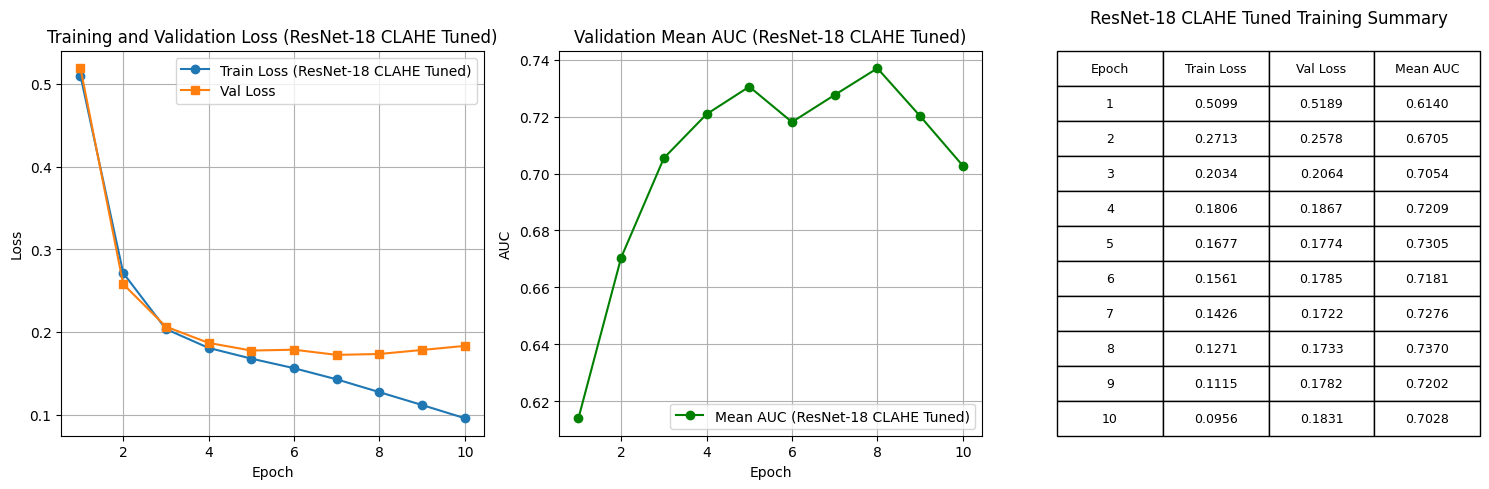

Training curves for ResNet-18 CLAHE-tuned model saved to 'resnet18_clahe_tuned_training_curves.png'

RESNET-18 CLAHE TUNED MODEL FINAL RESULTS SUMMARY
Best Validation AUC: 0.7370 (Epoch 8)
Final Validation AUC: 0.7028
Final Train Loss: 0.0956
Final Val Loss: 0.1831
ResNet-18 CLAHE-tuned model evaluation complete!


In [ ]:
import matplotlib.pyplot as plt
import torch

print("Generating training curves and summary for ResNet-18 CLAHE-tuned model...")

# Plot Training Curves
plt.figure(figsize=(15, 5))

# Loss curves
plt.subplot(1, 3, 1)
plt.plot(range(1, NUM_EPOCHS_RESNET_CLAHE_TUNED+1), train_losses_resnet_clahe_tuned, marker='o', label='Train Loss (ResNet-18 CLAHE Tuned)')
plt.plot(range(1, NUM_EPOCHS_RESNET_CLAHE_TUNED+1), val_losses_resnet_clahe_tuned, marker='s', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss (ResNet-18 CLAHE Tuned)')
plt.legend()
plt.grid(True)

# AUC curve
plt.subplot(1, 3, 2)
plt.plot(range(1, NUM_EPOCHS_RESNET_CLAHE_TUNED+1), val_aucs_resnet_clahe_tuned, marker='o', color='green', label='Mean AUC (ResNet-18 CLAHE Tuned)')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.title('Validation Mean AUC (ResNet-18 CLAHE Tuned)')
plt.legend()
plt.grid(True)

# Summary table
plt.subplot(1, 3, 3)
plt.axis('off')
summary_data_resnet_clahe_tuned = [
    [i+1, f"{train_losses_resnet_clahe_tuned[i]:.4f}", f"{val_losses_resnet_clahe_tuned[i]:.4f}", f"{val_aucs_resnet_clahe_tuned[i]:.4f}"]
    for i in range(NUM_EPOCHS_RESNET_CLAHE_TUNED)
]

table = plt.table(cellText=summary_data_resnet_clahe_tuned,
                  colLabels=['Epoch', 'Train Loss', 'Val Loss', 'Mean AUC'],
                  cellLoc='center',
                  loc='center',
                  bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)
plt.title('ResNet-18 CLAHE Tuned Training Summary', pad=20)

plt.tight_layout()
plt.savefig('resnet18_clahe_tuned_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("Training curves for ResNet-18 CLAHE-tuned model saved to 'resnet18_clahe_tuned_training_curves.png'")

# Final Results Summary for ResNet-18 CLAHE-tuned Model
print("\n" + "="*60)
print("RESNET-18 CLAHE TUNED MODEL FINAL RESULTS SUMMARY")
print("="*60)
best_auc_idx_resnet_clahe_tuned = val_aucs_resnet_clahe_tuned.index(max(val_aucs_resnet_clahe_tuned))
print(f"Best Validation AUC: {max(val_aucs_resnet_clahe_tuned):.4f} (Epoch {best_auc_idx_resnet_clahe_tuned+1})")
print(f"Final Validation AUC: {val_aucs_resnet_clahe_tuned[-1]:.4f}")
print(f"Final Train Loss: {train_losses_resnet_clahe_tuned[-1]:.4f}")
print(f"Final Val Loss: {val_losses_resnet_clahe_tuned[-1]:.4f}")
print("="*60)
print("ResNet-18 CLAHE-tuned model evaluation complete!")
print("===========================================================")